# 7. L-Systems and Botanical Form

A grammar of three rules can grow a fern. Today we build the L-system, the most botanical of all algorithms: strings that rewrite themselves into plants, a turtle that reads them, and a stack that remembers where the branch forked.

## Today's destination

A herbarium sheet of six plants that never grew. Each specimen on the sheet is a different *species* in a precise sense: a different set of rewriting rules, drawn by the same dozen lines of code. By the end of today you can define new species yourself, and the exercise asks you to name one.

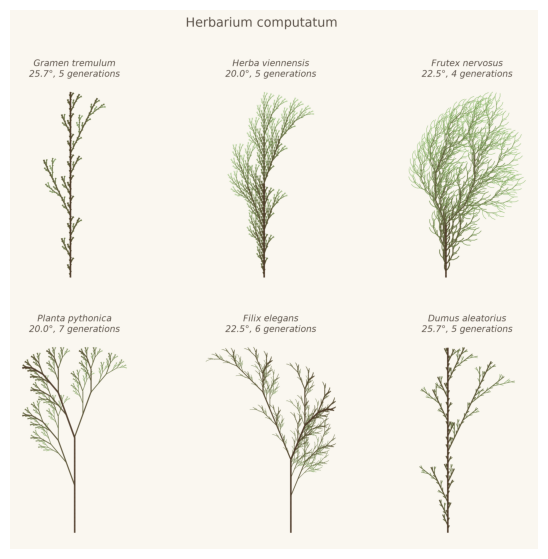

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch07_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(10, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: the algorithm hiding in the herbarium

For most of its history, European art met plants through the discipline of close looking. Basilius Besler's <a class="cite" href="#ref-besler1613">*Hortus Eystettensis* (1613)</a> recorded the garden of the prince-bishop of Eichstätt in hundreds of engraved plates, plant by plant, at full folio size. **Maria Sibylla Merian** (1647-1717) went further than looking: she raised the insects she painted, sailed to Surinam, and published the <a class="cite" href="#ref-merian1705">*Metamorphosis insectorum Surinamensium* (1705)</a>, where plant and insect appear together as one living system, not as isolated specimens. And at the century's turn, the zoologist **Ernst Haeckel** issued <a class="cite" href="#ref-haeckel1899">*Kunstformen der Natur* (1899-1904)</a>, a hundred lithographic plates of radiolarians, medusae, orchids and mosses arranged with such symmetry that natural history tipped over into ornament. The plates fed straight into Jugendstil. René Binet had long admired the radiolarian plates of Haeckel's earlier *Challenger* expedition reports; his monumental entrance gate for the Paris World's Fair of 1900 was designed after one of those radiolarians, as he wrote to Haeckel himself <a class="cite" href="#ref-proctor2006">(Proctor 2006)</a>.

All of this art records the *forms* of plants. In 1917 the biologist **D'Arcy Wentworth Thompson** published <a class="cite" href="#ref-thompson1917">*On Growth and Form*</a> and shifted the question: form, he argued, is the visible trace of the *process* that made it, and processes can be written in mathematics. Half a century later the theoretical biologist **Aristid Lindenmayer** (1925-1989) made that idea precise for growth itself. In 1968 he proposed modeling the development of simple filamentous organisms as **string rewriting** <a class="cite" href="#ref-lindenmayer1968">(Lindenmayer 1968)</a>: the state of the organism is a string of symbols, and growth is the repeated application of replacement rules (Ersetzungsregeln). These *Lindenmayer systems*, L-systems for short, turned out to scale far beyond algae. With Przemysław Prusinkiewicz, Lindenmayer showed that a handful of rules generates convincing herbs, ferns and trees; their book <a class="cite" href="#ref-prusinkiewicz1990">*The Algorithmic Beauty of Plants* (1990)</a> is the classic of the field, freely available online, and the source of every plant we grow today.

The L-system fern is also this course's emblem. When the course description says *creative coding, not prompt typing*, the fern is exhibit A: three rules you can read aloud, a growth process you can watch symbol by symbol, and a plant at the end that you understand completely because you grew it. Nothing about it is a black box, and everything about it is yours to vary.

## An alphabet for growth

An L-system needs three things, and all three are strings:

- an **alphabet**: the symbols we are allowed to use, for example `A`, `B`, `F`, `+`, `-`;
- an **axiom** (Axiom): the starting string, the seed of the organism;
- **production rules**: for each symbol, what it becomes in the next generation.

Growth is rewriting: go through the current string symbol by symbol, replace each symbol by its rule's right-hand side (symbols without a rule stay as they are), and the result is the next generation. That is the whole mechanism.

Lindenmayer's original example models a filament of algae cells in two states, `A` (mature) and `B` (young): a mature cell divides (`A` becomes `AB`), a young cell matures (`B` becomes `A`) <a class="cite" href="#ref-lindenmayer1968">(Lindenmayer 1968)</a>. In Python, the rules are a dictionary from chapter 0, and the rewriting engine is a loop of a few lines.

In [2]:
# the whole L-system engine: rewrite every symbol by its rule, n times
def rewrite(axiom, rules, iterations):
    string = axiom
    for step in range(iterations):
        next_string = ""
        for symbol in string:
            # .get: the symbol's rule if it has one, else the symbol unchanged
            next_string = next_string + rules.get(symbol, symbol)
        string = next_string
    return string

algae_rules = {"A": "AB", "B": "A"}
for generation in range(6):
    string = rewrite("A", algae_rules, generation)
    print(f"generation {generation}: length {len(string):2d}   {string}")

generation 0: length  1   A
generation 1: length  2   AB
generation 2: length  3   ABA
generation 3: length  5   ABAAB
generation 4: length  8   ABAABABA
generation 5: length 13   ABAABABAABAAB


Watch the string literally grow, and look at the lengths: 1, 2, 3, 5, 8, 13. The Fibonacci numbers fall out of Lindenmayer's algae by themselves, which is a good early warning that these systems grow *fast*: most useful rules at least double the string each generation, so ten generations can mean thousands of symbols. Like `depth` in chapter 5, the `iterations` parameter is a powerful dial that mostly wants to stay small.

**Try it.** Change the algae rules in the cell above, say `"A": "ABB"`, and predict the first five lengths before you rerun.

## The turtle: from string to drawing

So far the organism is only a string. To see it, we borrow the classic **turtle** metaphor: imagine a turtle sitting on the canvas with a position and a heading, reading the string symbol by symbol as commands:

| symbol | command |
|:------:|---------|
| `F` | walk one step forward, drawing a line |
| `+` | turn left by the fixed angle |
| `-` | turn right by the fixed angle |
| `[` | remember the current position and heading |
| `]` | jump back to the last remembered position and heading |

Any other symbol is ignored by the turtle; grammars often use letters like `X` as pure growth buds that shape the rewriting but draw nothing.

The turtle's step is chapter 3's unit circle again: from position $(x, y)$ with heading $\theta$, one step forward lands on $(x + \cos\theta,\; y + \sin\theta)$. And the remembering in `[` and `]` is a **stack** (Stapelspeicher): a plain Python list where `[` does `append`, which you have had since chapter 0, and `]` does `pop`, its inverse: remove and return the last item. The last position remembered is the first one restored, which is exactly how branches work: finish the side branch, then return to the fork.

In [3]:
# the turtle: read a string of commands, return the line segments it draws
import math

def interpret(instructions, angle_degrees, step=1.0):
    x, y = 0.0, 0.0
    heading = math.pi / 2                  # start pointing up, like a plant
    turn = math.radians(angle_degrees)
    stack = []
    segments = []                          # each entry: ((x1, y1), (x2, y2))
    depths = []                            # how many brackets deep the segment sits
    for symbol in instructions:
        if symbol == "F":
            x_new = x + step * math.cos(heading)
            y_new = y + step * math.sin(heading)
            segments.append(((x, y), (x_new, y_new)))
            depths.append(len(stack))
            x, y = x_new, y_new
        elif symbol == "+":
            heading = heading + turn
        elif symbol == "-":
            heading = heading - turn
        elif symbol == "[":
            stack.append((x, y, heading))
        elif symbol == "]":
            x, y, heading = stack.pop()
    return segments, depths

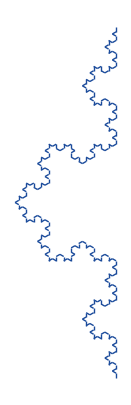

string length 596, segments drawn: 256


In [4]:
# see the strings as lines: chapter 4's LineCollection, thousands of segments fast
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def draw_segments(segments, color="#1A1A1A", linewidth=1.2, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    ax.add_collection(LineCollection(segments, colors=color, linewidths=linewidth))
    ax.autoscale()
    ax.set_aspect("equal")
    ax.axis("off")
    return ax

# validation on a famous non-plant: the Koch curve, four generations
koch = rewrite("F", {"F": "F+F--F+F"}, 4)
segments, depths = interpret(koch, angle_degrees=60)
draw_segments(segments, color="#1B4B9B", linewidth=1.0)
plt.show()
print(f"string length {len(koch)}, segments drawn: {len(segments)}")

One rule, and the turtle draws the **Koch curve**, the classic mathematical monster from 1904 <a class="cite" href="#ref-koch1904">(Koch 1904)</a> that chapter 8 will meet again as a fractal. Each generation replaces every segment by four smaller ones, so the segment counts run $4, 16, 64, 256$: there is the exponential growth again, now visible as ever finer detail.

**Try it.** Set `iterations` in the `rewrite` call to 1, then 2, then 5. At 1 you can read the rule directly in the drawing: forward, left, forward, twice right, forward, left, forward.

## Brackets: how plants branch

The Koch curve never branches: the turtle walks one endless path. Plants fork, and the bracket symbols are the fork. Read `F[+F][-F]F` aloud as a botanist: grow a stem, remember this spot, grow a twig to the left, come back, grow a twig to the right, come back, keep growing upward.

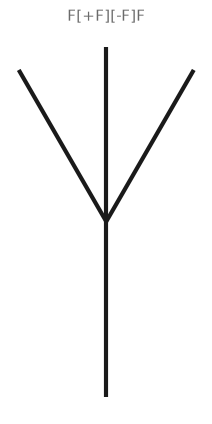

In [5]:
# the smallest branching plant: one stem, two twigs, then upward again
segments, depths = interpret("F[+F][-F]F", angle_degrees=30)
ax = draw_segments(segments, linewidth=3)
ax.set_title("F[+F][-F]F", fontsize=11, color="#6B6B6B")
plt.show()

Now let the rewriting engine and the brackets work together. The classic plant below comes from *The Algorithmic Beauty of Plants* (figure 1.24f; <a class="cite" href="#ref-prusinkiewicz1990">Prusinkiewicz and Lindenmayer 1990</a>): the symbol `X` is a growth bud that never draws, `F` is a stem piece that doubles each generation. Five generations turn one bud into a plant of several thousand symbols.

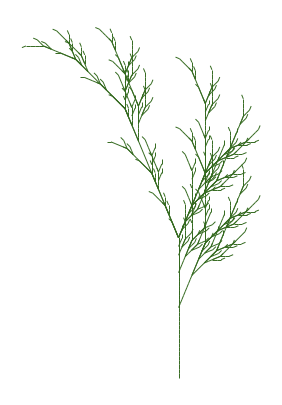

6263 symbols, 1488 segments, deepest branching level: 9


In [6]:
# a classic from The Algorithmic Beauty of Plants: plant 1.24f, five generations
fern_rules = {"X": "F-[[X]+X]+F[+FX]-X", "F": "FF"}
fern = rewrite("X", fern_rules, 5)
segments, depths = interpret(fern, angle_degrees=22.5)
draw_segments(segments, color="#33691E", linewidth=0.7)
plt.show()
print(f"{len(fern)} symbols, {len(segments)} segments, "
      f"deepest branching level: {max(depths)}")

**Try it.** The branching angle is the plant's temperament. Rerun the cell with `angle_degrees=12` (a poplar, nervous and upright), then `35` (a sprawling shrub). The slider below sweeps the angle live; where widgets do not run, calling `plant_explorer(25.0)` directly does the same.

In [7]:
# optional slider -- everything it does, a direct call to plant_explorer does too
def plant_explorer(angle=22.5):
    body = rewrite("X", fern_rules, 4)
    segments, depths = interpret(body, angle_degrees=angle)
    ax = draw_segments(segments, color="#33691E", linewidth=1.0)
    ax.set_title(f"branching angle {angle:.1f}°", fontsize=10, color="#6B6B6B")
    plt.show()

try:
    from ipywidgets import interact
    interact(plant_explorer, angle=(5.0, 45.0, 0.5))
except ImportError:
    print("ipywidgets is not installed -- call plant_explorer(angle) directly")

interactive(children=(FloatSlider(value=22.5, description='angle', max=45.0, min=5.0, step=0.5), Output()), _d…

## Chance grows a garden

Every plant we have grown so far is deterministic: same rules, same plant, down to the last twig. Real clover leaves differ. The fix is the **stochastic L-system**: a symbol may have several competing productions, each with a probability, and the rewriting engine rolls dice at every replacement. Randomness is back, so `rng = np.random.default_rng(seed)` from chapter 2 returns with it, and one seed grows one specific individual, reproducibly.

The rule set below is the stochastic example from *The Algorithmic Beauty of Plants* <a class="cite" href="#ref-prusinkiewicz1990">(Prusinkiewicz and Lindenmayer 1990)</a>: one stem symbol, three possible growth patterns, equal thirds.

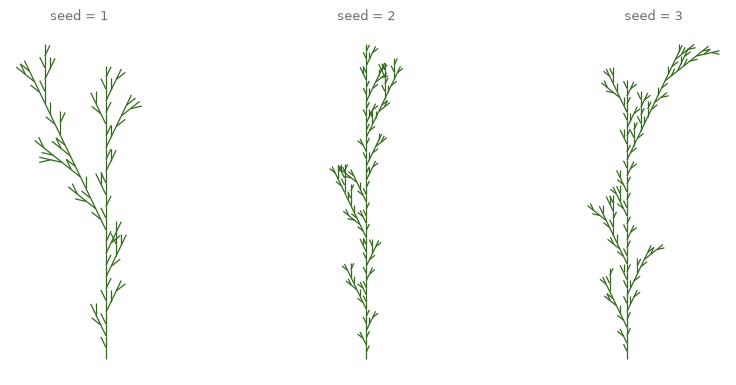

In [7]:
# stochastic rewriting: a symbol can have several productions with probabilities
import numpy as np

def rewrite_stochastic(axiom, rules, iterations, rng):
    string = axiom
    for step in range(iterations):
        next_string = ""
        for symbol in string:
            if symbol in rules:
                options, probabilities = rules[symbol]
                choice = rng.choice(len(options), p=probabilities)
                next_string = next_string + options[choice]
            else:
                next_string = next_string + symbol
        string = next_string
    return string

bush_rules = {"F": (["F[+F]F[-F]F", "F[+F]F", "F[-F]F"], [1 / 3, 1 / 3, 1 / 3])}

fig, axes = plt.subplots(1, 3, figsize=(10.5, 4.5))
for i in range(3):
    rng = np.random.default_rng(i + 1)
    body = rewrite_stochastic("F", bush_rules, 4, rng)
    draw_segments(interpret(body, 25.7)[0], color="#33691E",
                  linewidth=0.9, ax=axes[i])
    axes[i].set_title(f"seed = {i + 1}", fontsize=9, color="#6B6B6B")
plt.show()

Three individuals of one species: clearly siblings, clearly not clones. This is the difference between a pattern and a population, and it is what will make the herbarium sheet feel alive.

## Dressing the plant

Two aesthetic touches turn stick diagrams into botanical drawings, and both ride on the `depths` list our turtle already records. A real stem is thick at the trunk and thin at the twigs: let the line width shrink with bracket depth. And foliage is lighter than wood: let the color fade from a dark trunk brown-green toward a pale leaf green as depth grows. Both are one formula each, applied per segment through `LineCollection`.

In [8]:
# color blending tools, and the course helpers: paper ground, artwork saving
import sys
sys.path.append("..")
from matplotlib.colors import to_rgb
from agap.helpers import PAPER, save_artwork

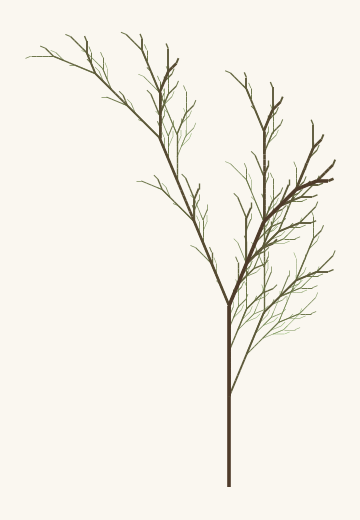

In [9]:
# depth-aware drawing: thick dark trunk, thin pale twigs
def draw_plant(segments, depths, ax, trunk="#4E3B2A", leaf="#8FBC6D",
               base_width=2.6, shrink=0.72):
    trunk_rgb = np.array(to_rgb(trunk))
    leaf_rgb = np.array(to_rgb(leaf))
    deepest = max(max(depths), 1)
    colors = []
    widths = []
    for depth in depths:
        blend = depth / deepest                  # 0 at the trunk, 1 at the tips
        colors.append((1 - blend) * trunk_rgb + blend * leaf_rgb)
        widths.append(max(0.35, base_width * shrink ** depth))
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=widths))
    ax.autoscale()
    ax.set_aspect("equal")
    ax.axis("off")

fig, ax = plt.subplots(figsize=(6.5, 6.5), facecolor=PAPER)
segments, depths = interpret(rewrite("X", fern_rules, 5), 22.5)
draw_plant(segments, depths, ax)
plt.show()

## Playground: a book of species

Time to collect. Each entry below is one *species*: an axiom, rules, a branching angle, and a number of generations. The first five are the classic plants from *The Algorithmic Beauty of Plants* (figure 1.24; <a class="cite" href="#ref-prusinkiewicz1990">Prusinkiewicz and Lindenmayer 1990</a>); the last one is our stochastic bush, which additionally takes a seed. The generator grows any of them onto an axis, so sheets of several plants are just subplot loops, the pattern you know from chapter 5's Mondrian sheet. In the code, a stochastic species is recognizable by its rules holding a `(options, probabilities)` tuple instead of a plain string; `isinstance` asks which of the two a value is.

In [10]:
# six species: axiom, rules, angle, generations (stochastic ones carry "p")
SPECIES = {
    "Gramen tremulum":   {"axiom": "F", "angle": 25.7, "n": 5,
                          "rules": {"F": "F[+F]F[-F]F"}},
    "Herba viennensis":  {"axiom": "F", "angle": 20.0, "n": 5,
                          "rules": {"F": "F[+F]F[-F][F]"}},
    "Frutex nervosus":   {"axiom": "F", "angle": 22.5, "n": 4,
                          "rules": {"F": "FF-[-F+F+F]+[+F-F-F]"}},
    "Planta pythonica":  {"axiom": "X", "angle": 20.0, "n": 7,
                          "rules": {"X": "F[+X]F[-X]+X", "F": "FF"}},
    "Filix elegans":     {"axiom": "X", "angle": 22.5, "n": 6,
                          "rules": {"X": "F-[[X]+X]+F[+FX]-X", "F": "FF"}},
    "Dumus aleatorius":  {"axiom": "F", "angle": 25.7, "n": 5,
                          "rules": {"F": (["F[+F]F[-F]F", "F[+F]F", "F[-F]F"],
                                          [1 / 3, 1 / 3, 1 / 3])}},
}

def grow(name, seed=1):
    species = SPECIES[name]
    stochastic = isinstance(list(species["rules"].values())[0], tuple)
    if stochastic:
        rng = np.random.default_rng(seed)
        body = rewrite_stochastic(species["axiom"], species["rules"],
                                  species["n"], rng)
    else:
        body = rewrite(species["axiom"], species["rules"], species["n"])
    return interpret(body, species["angle"])

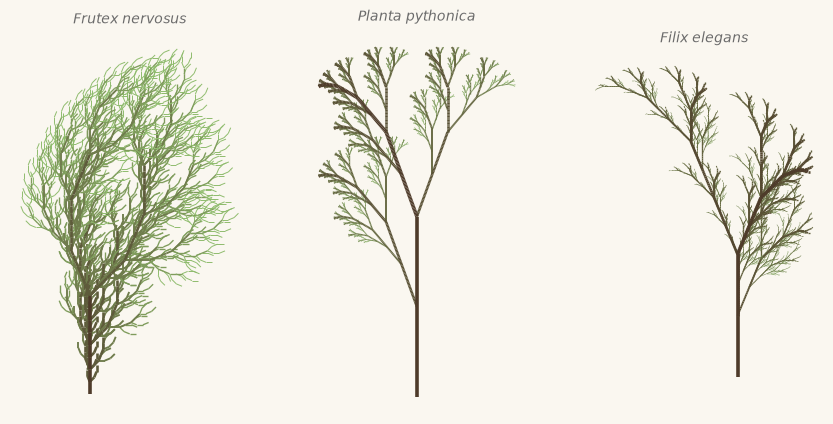

In [11]:
# temperament 1: the same renderer, three very different species
fig, axes = plt.subplots(1, 3, figsize=(10.5, 5), facecolor=PAPER)
# zip pairs the axes with the names, walking both lists in lockstep
for ax, name in zip(axes, ["Frutex nervosus", "Planta pythonica", "Filix elegans"]):
    segments, depths = grow(name)
    draw_plant(segments, depths, ax)
    ax.set_title(name, fontsize=10, style="italic", color="#6B6B6B")
plt.show()

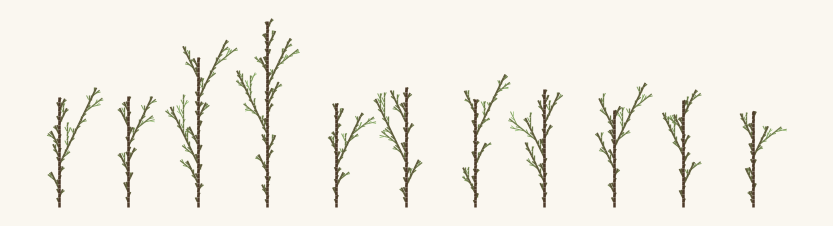

In [12]:
# temperament 2: a hedgerow -- one stochastic species, eleven individuals
fig, ax = plt.subplots(figsize=(10.5, 4), facecolor=PAPER)
rng = np.random.default_rng(7)
for position in range(11):
    plant_rng = np.random.default_rng(100 + position)
    body = rewrite_stochastic("F", bush_rules, 4, plant_rng)
    segments, depths = interpret(body, 25.7)
    size = rng.uniform(0.7, 1.05)              # every plant its own stature
    shifted = []
    for (x1, y1), (x2, y2) in segments:
        shifted.append(((x1 * size + position * 14, y1 * size),
                        (x2 * size + position * 14, y2 * size)))
    draw_plant(shifted, depths, ax, base_width=1.8)
plt.show()

**Look and compare.** In the hedgerow, can you still tell that all eleven plants share one rule set, and how? And between *Planta pythonica* and *Filix elegans*: which reads more like a fern, and is it the angle, the rules, or the sheer segment count that convinces you? Botanical illustrators made exactly these judgment calls when they idealized a specimen into a plate; you are now making them with parameters.

## The showpiece: a herbarium sheet

A herbarium mounts specimens on paper sheets with handwritten labels. Ours mounts all six species, each with an invented Latin name in the labeling style of the genre (the names are fiction, the growth rules are the real taxonomy). This is today's artwork: not one plant, but the *comparison* of six grammars.

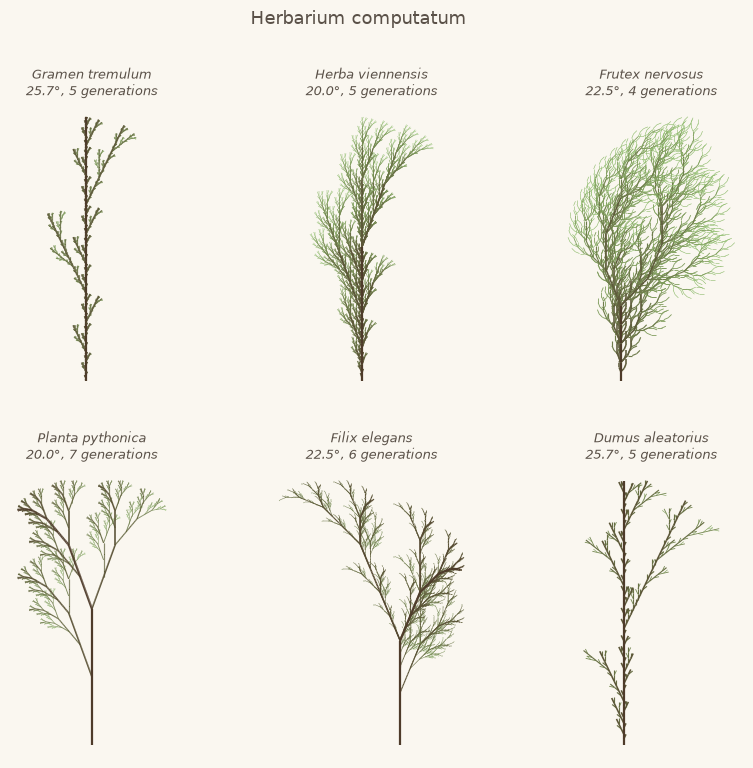

In [13]:
# the showpiece generator: six species mounted as a herbarium sheet
def herbarium_sheet():
    fig, axes = plt.subplots(2, 3, figsize=(10.5, 8.5), facecolor=PAPER)
    for ax, name in zip(axes.flat, SPECIES):
        segments, depths = grow(name, seed=4)
        draw_plant(segments, depths, ax, base_width=1.6)
        species = SPECIES[name]
        label = f"{name}\n{species['angle']}°, {species['n']} generations"
        ax.set_title(label, fontsize=9, style="italic", color="#5A5148")
    fig.suptitle("Herbarium computatum", fontsize=13, color="#5A5148", y=0.99)
    fig.subplots_adjust(wspace=0.1, hspace=0.25)
    plt.show()
    return fig

showpiece = herbarium_sheet()

## Export your artwork

Grow a species of your own, or a variation of one from the book, then export it. Replace `yourname` and run; the print-quality PNG lands in `assets/outputs/`. The `seed` matters only for the stochastic *Dumus aleatorius*; the deterministic species ignore it.

saved: assets/outputs/ch07_yourname.png


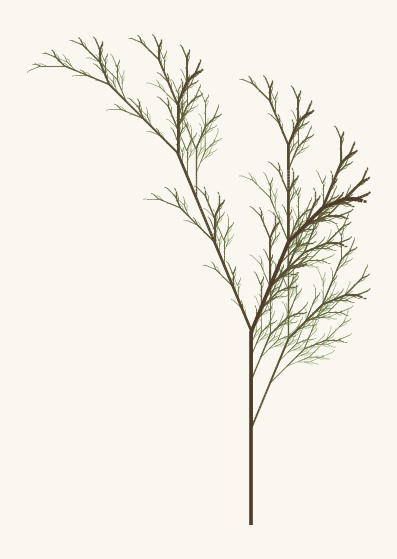

In [14]:
# save YOUR artwork: adjust species and seed, replace 'yourname', run the cell
fig, ax = plt.subplots(figsize=(7, 7), facecolor=PAPER)
segments, depths = grow("Filix elegans", seed=2026)
draw_plant(segments, depths, ax)
saved_path = save_artwork(fig, "yourname", chapter=7)

## Exercises

**(a) Parameter exploration: the natural angle.** Sweep the branching angle of *Planta pythonica* from 15° to 35° in steps of 5° (five calls, or one loop over subplots). Somewhere in that range the plant flips from "diagram of a plant" to "plant". Where is it for you, and does your neighbor agree? The classic plants of *The Algorithmic Beauty of Plants* all set their branching angles between 20° and 25.7° <a class="cite" href="#ref-prusinkiewicz1990">(Prusinkiewicz and Lindenmayer 1990)</a>; aesthetics may or may not care.

**(b) Code modification: flowers.** Give a plant flowers: extend the turtle so that a new symbol `O` draws a red dot at the current position, then grow a species whose branch tips carry `O`. The trick: in bud grammars like *Planta pythonica*, every `X` still in the final string *is* a tip that never grew further. Replace them.

<details><summary>Solution</summary>

```python
def interpret_with_flowers(instructions, angle_degrees, step=1.0):
    x, y = 0.0, 0.0
    heading = math.pi / 2
    turn = math.radians(angle_degrees)
    stack, segments, depths, flowers = [], [], [], []
    for symbol in instructions:
        if symbol == "F":
            x_new = x + step * math.cos(heading)
            y_new = y + step * math.sin(heading)
            segments.append(((x, y), (x_new, y_new)))
            depths.append(len(stack))
            x, y = x_new, y_new
        elif symbol == "+":
            heading = heading + turn
        elif symbol == "-":
            heading = heading - turn
        elif symbol == "[":
            stack.append((x, y, heading))
        elif symbol == "]":
            x, y, heading = stack.pop()
        elif symbol == "O":
            flowers.append((x, y))
    return segments, depths, flowers

body = rewrite("X", {"X": "F[+X]F[-X]+X", "F": "FF"}, 6)
body = body.replace("X", "O")          # every leftover bud becomes a flower
segments, depths, flowers = interpret_with_flowers(body, 20.0)

fig, ax = plt.subplots(figsize=(7, 7), facecolor=PAPER)
draw_plant(segments, depths, ax, base_width=2.2)
xs = []
ys = []
for x, y in flowers:
    xs.append(x)
    ys.append(y)
ax.scatter(xs, ys, s=6, color="#D02433", zorder=3)
plt.show()
```

The turtle gains exactly one `elif`; everything else is the rewriting doing the botany. Try smaller dot sizes and a paler red; flowers overwhelm quickly.
</details>

**(c) Creative challenge: found a species.** Invent a rule set of your own, grow it, and name it Latin-style (*genus* + *species*, italics, a connoisseur's understatement). Rules of the genre: change only one thing at a time while breeding, keep generations low while experimenting, and when something half-works, save the rules before you keep breeding. Bring your named specimen to the gallery; the class herbarium grows by whatever survives.

## Further reading

- Przemysław Prusinkiewicz and Aristid Lindenmayer, *The Algorithmic Beauty of Plants* (Springer, 1990): the classic, beautiful and precise, [free as PDF from the Algorithmic Botany group](http://algorithmicbotany.org/papers/#abop) whose site collects three decades of follow-up work.
- D'Arcy Wentworth Thompson, *On Growth and Form* (1917): the great argument that biological form is written mathematics; the original is in the public domain and easy to find as a scan.
- Ernst Haeckel, *Kunstformen der Natur* (1899-1904): browse all hundred plates via the [Wikipedia overview](https://en.wikipedia.org/wiki/Kunstformen_der_Natur) and watch systematic biology become Jugendstil ornament plate by plate.
- Maria Sibylla Merian, *Metamorphosis insectorum Surinamensium* (1705): the counterpoint to everything generated today, form earned by raising the actual caterpillars.

## References

- <span id="ref-besler1613"></span>Besler, B. (1613). *Hortus Eystettensis*. Nuremberg. 367 engraved folio plates recording the garden of the prince-bishop of Eichstätt.
- <span id="ref-haeckel1899"></span>Haeckel, E. (1899–1904). *Kunstformen der Natur*. Bibliographisches Institut, Leipzig and Vienna. One hundred lithographic plates, issued in installments; the bridge from systematic biology to Jugendstil ornament.
- <span id="ref-koch1904"></span>Koch, H. von (1904). Sur une courbe continue sans tangente, obtenue par une construction géométrique élémentaire. *Arkiv för Matematik, Astronomi och Fysik*, 1, 681–704. The original construction of the Koch curve.
- <span id="ref-lindenmayer1968"></span>Lindenmayer, A. (1968). Mathematical models for cellular interactions in development, Parts I and II. *Journal of Theoretical Biology*, 18(3), 280–299 and 300–315. [doi:10.1016/0022-5193(68)90079-9](https://doi.org/10.1016/0022-5193(68)90079-9), [doi:10.1016/0022-5193(68)90080-5](https://doi.org/10.1016/0022-5193(68)90080-5). The founding papers of L-systems, including the two-state filament example grown in this chapter.
- <span id="ref-merian1705"></span>Merian, M. S. (1705). *Metamorphosis insectorum Surinamensium*. Amsterdam. Plants and insects observed as one living system, from her own rearing and her Surinam voyage.
- <span id="ref-proctor2006"></span>Proctor, R. (2006). Architecture from the cell-soul: René Binet and Ernst Haeckel. *The Journal of Architecture*, 11(4), 407–424. [doi:10.1080/13602360601037818](https://doi.org/10.1080/13602360601037818). Documents Binet's radiolarian-derived 1900 gate and his correspondence with Haeckel.
- <span id="ref-prusinkiewicz1990"></span>Prusinkiewicz, P., and Lindenmayer, A. (1990). *The Algorithmic Beauty of Plants*. Springer-Verlag, New York. [doi:10.1007/978-1-4613-8476-2](https://doi.org/10.1007/978-1-4613-8476-2); free PDF at [algorithmicbotany.org](http://algorithmicbotany.org/papers/#abop). Source of the deterministic species (figure 1.24) and the stochastic example.
- <span id="ref-thompson1917"></span>Thompson, D'A. W. (1917). *On Growth and Form*. Cambridge University Press. Form as the visible trace of mathematically describable process.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook. It runs automatically with *Restart & Run All*.

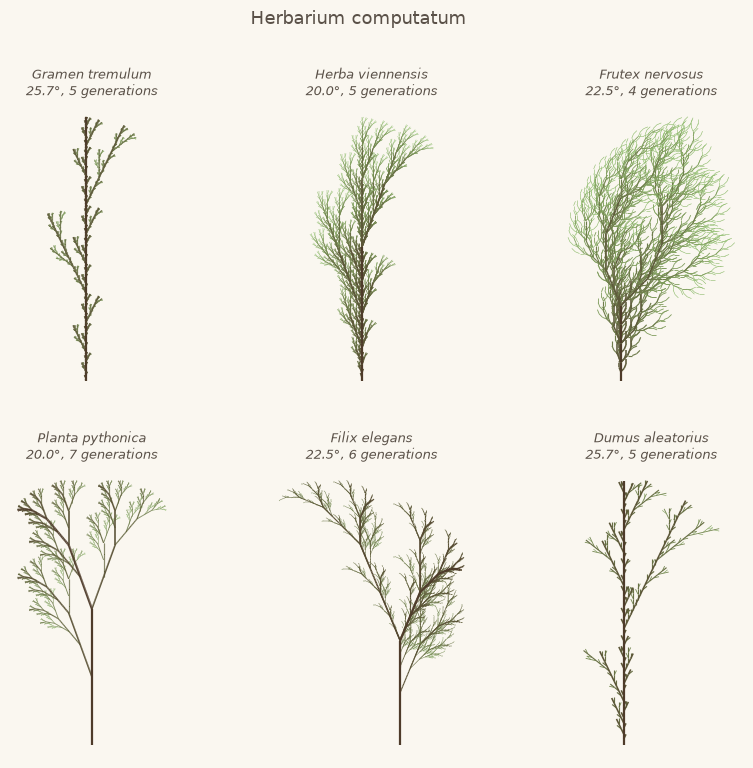

saved: assets/outputs/ch07_showpiece.png


In [15]:
# regenerate this chapter's showpiece: the herbarium sheet
showpiece = herbarium_sheet()
saved_path = save_artwork(showpiece, "showpiece", chapter=7)